## Teletransportación cuántica
Se "mueve" el estado de un qubit (q0) a otro (q2) usando un par entrelazado (q1, q2).
Usamos la versión con compuertas controladas en lugar de mediciones intermedias.

In [1]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()

def correr(qc, shots=1024):
    """Ejecuta un circuito en el simulador y devuelve los conteos."""
    return sim.run(transpile(qc, sim), shots=shots).result().get_counts()

Resultado teletransportado: {'1': 321, '0': 703}
Probabilidad teórica de '1': 0.319


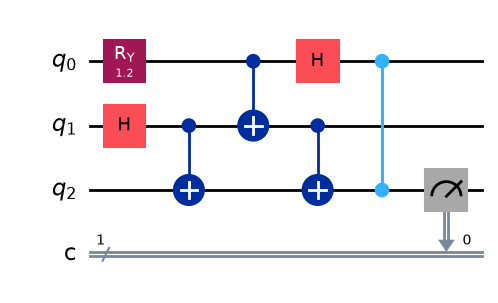

In [2]:
theta = 1.2   # estado a teletransportar: Ry(theta)|0>

qc = QuantumCircuit(3, 1)
qc.ry(theta, 0)          # estado "secreto" de Alice
qc.h(1); qc.cx(1, 2)     # par de Bell entre q1 y q2
qc.cx(0, 1); qc.h(0)     # medición de Bell (en forma diferida)
qc.cx(1, 2); qc.cz(0, 2) # correcciones de Bob
qc.measure(2, 0)

print("Resultado teletransportado:", correr(qc))
print("Probabilidad teórica de '1':", round(np.sin(theta/2)**2, 3))
qc.draw("mpl")